## Q2.Unsupervised Learning

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('q2_customers.csv')

# Display basic info
print(df.head())
print(df.shape)

   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  
(500, 6)


In [2]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


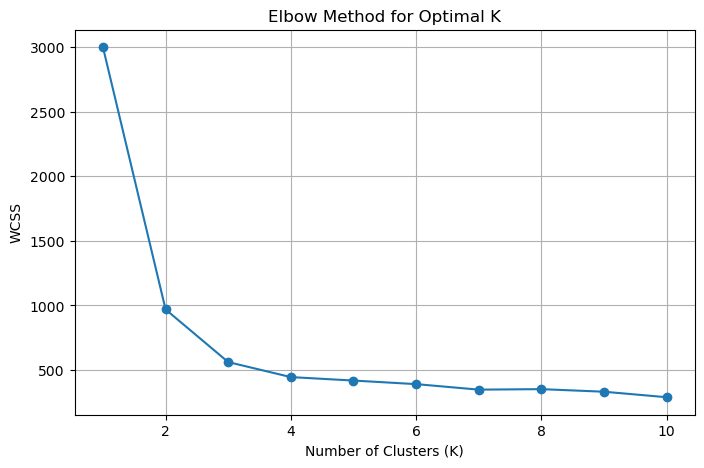

In [3]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

## KMeans

In [4]:
optimal_k = 3  

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(scaled_df)

# Add cluster labels
df['cluster'] = clusters

df.head()
## K-Means clustering is based on distance.

## StandardScaler ensures all features contribute equally by transforming them to have mean = 0 and standard deviation = 1.

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [5]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1] 
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


## PCA

In [6]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

# Create dataframe
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = clusters

pca_df.head()

,PC1,PC2,cluster
0,-0.333082,0.109379,2
1,-2.255362,0.048458,0
2,-0.092905,-0.679257,2
3,-2.017598,-0.308845,0
4,-2.917762,0.529368,0


In [7]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [8]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


## Cluster Visualization

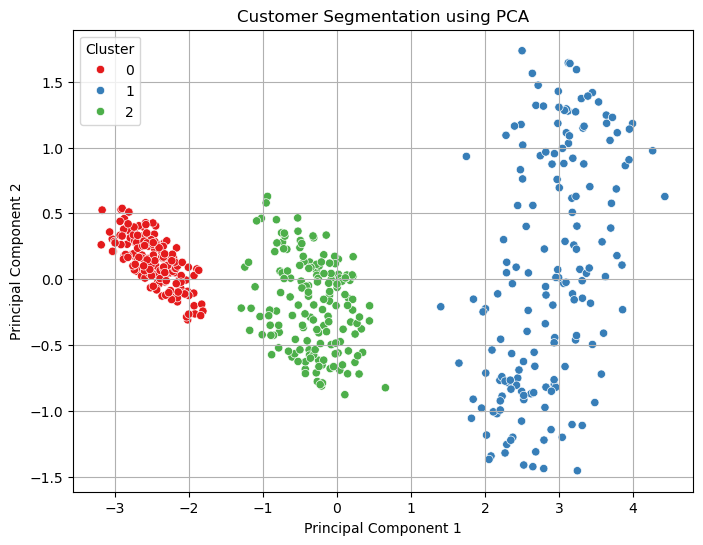

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    data=pca_df,
    palette='Set1'
)

plt.title('Customer Segmentation using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)

plt.show()